In [2]:
pip install cvxpy

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------- ----------------------- 0.5/1.3 MB 2.0 MB/s eta 0:00:01
   -------------------------------- ------- 1.0/1.3 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/887.3 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/887.3 kB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 887.3/887.3 kB 4.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.4 MB 5.6 MB/s eta 0:00:01
   -------------------------- ------------- 1.6/2.4 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------  2.4/2.4 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 3.8 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    ----------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.signal import place_poles

In [2]:
def generate_A(n):

    A = np.zeros((n,n))

    for i in range(n):
        A[i,i] = 0.9 + 0.1*np.random.rand()

        if i>0:
            A[i,i-1] = 0.07 + 0.02*np.random.rand()

        if i<n-1:
            A[i,i+1] = -0.09 + 0.02*np.random.rand()

    return A
# def generate_C(n,p):

#     C = np.random.randn(p,n)

#     # Normalize rows
#     C = C / np.linalg.norm(C,axis=1,keepdims=True)

#     return C
def generate_C(n,p):

    C = np.zeros((p,n))
    C[:, :p] = np.eye(p)

    return C

def simulate_system(
        A,B,C,
        T,
        sigma_w,
        sigma_v,
        s,
        corruption_mag=5):

    n = A.shape[0]
    p = C.shape[0]

    x = np.zeros((T,n))
    y = np.zeros((T,p))

    w = sigma_w*np.random.randn(T,n)
    v = sigma_v*np.random.randn(T,p)

    # sparse corruption

    corrupted = np.random.choice(p,s,replace=False)

    e = np.zeros((T,p))

    for i in corrupted:
        # bias = corruption_mag*np.random.randn()
        # e[:,i] = bias
        e[:,i] = corruption_mag*np.random.randn(T)

    x[0] = np.random.randn(n)

    def compute_K(A,B):

        n = A.shape[0]

        # choose stable poles
        poles = np.linspace(0.6,0.8,n)

        result = place_poles(A,B,poles)

        return result.gain_matrix
    K=compute_K(A,B)
    #print("K",K)
    for k in range(T-1):
        x[k+1] = A@x[k] + B@(-K@x[k]) + w[k]

    y = (C@x.T).T + e + v

    return x,y,e,corrupted


In [3]:
import cvxpy as cp

def batch_estimation(A,B,C,y,lam=1):

    T,p = y.shape
    n = A.shape[0]

    x = cp.Variable((T,n))
    e = cp.Variable((T,p))

    cost = 0

    for k in range(T):

        cost += cp.sum_squares(
            y[k] - C@x[k] - e[k]
        )

        cost += lam*cp.norm1(e[k])

    constraints = []

    for k in range(T-1):

        constraints += [
            x[k+1] == A@x[k]
        ]

    prob = cp.Problem(
        cp.Minimize(cost),
        constraints
    )

    prob.solve(solver=cp.OSQP)

    return x.value,e.value

In [4]:
def compute_errors(x_true,x_est,e_true,e_est):

    state_error = np.linalg.norm(
        x_true-x_est
    )/np.linalg.norm(x_true)

    corruption_error = np.linalg.norm(
        e_true-e_est
    )/np.linalg.norm(e_true)

    return state_error,corruption_error

In [5]:
def run_experiment():

    n = 12
    p = 6
    T = 500
    s = 2

    A = generate_A(n)

    B = np.zeros((n,1))
    B[0,0] = 1

    C = generate_C(n,p)

    sigma_w_list = np.array([0.01,0.05,0.1,0.15,0.2])
    sigma_v_list = np.array([0.01,0.05,0.1,0.15,0.2])

    results = np.zeros((
        len(sigma_w_list),
        len(sigma_v_list)
    ))

    for i, sigma_w in enumerate(sigma_w_list):

        for j, sigma_v in enumerate(sigma_v_list):

            x,y,e,_ = simulate_system(
                A,B,C,
                T,
                sigma_w,
                sigma_v,
                s
            )

            x_est,e_est = batch_estimation(
                A,B,C,y
            )

            _,corruption_err = compute_errors(
                x,x_est,e,e_est
            )

            results[i,j] = corruption_err

    return sigma_w_list, sigma_v_list, results

In [14]:
sigma_w_list, sigma_v_list, results = run_experiment()

In [8]:
def plot_process_noise(
        sigma_w_list,
        sigma_v_list,
        results):

    plt.figure(figsize=(7,5))

    for j, sigma_v in enumerate(sigma_v_list):

        plt.plot(
            sigma_w_list,
            results[:,j],
            marker='o',
            label=f"σ_v={sigma_v}"
        )

    plt.xlabel("Process noise std (σ_w)")
    plt.ylabel("Corruption recovery error")

    plt.title(
        "Process Noise vs Corruption Recovery Error"
    )

    plt.legend()
    plt.grid(True)

    plt.show()
def plot_measurement_noise(
        sigma_w_list,
        sigma_v_list,
        results):

    plt.figure(figsize=(7,5))

    for i, sigma_w in enumerate(sigma_w_list):

        plt.plot(
            sigma_v_list,
            results[i,:],
            marker='o',
            label=f"σ_w={sigma_w}"
        )

    plt.xlabel("Measurement noise std (σ_v)")
    plt.ylabel("Corruption recovery error")

    plt.title(
        "Measurement Noise vs Corruption Recovery Error"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

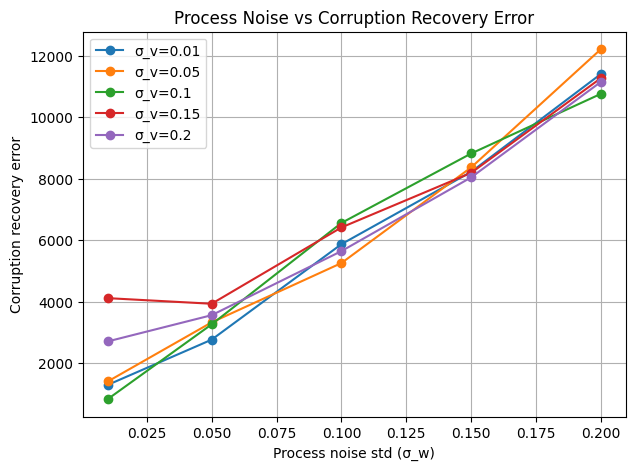

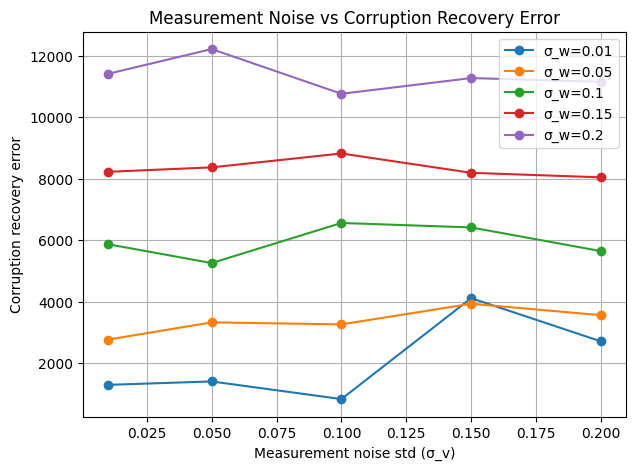

In [15]:
plot_process_noise(
    sigma_w_list,
    sigma_v_list,
    results
)

plot_measurement_noise(
    sigma_w_list,
    sigma_v_list,
    results
)

In [4]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.signal import place_poles
seed=42
np.random.seed(seed)
def generate_A(n):
    A = np.zeros((n, n))
    for i in range(n):
        A[i, i] = 0.9 + 0.1 * np.random.rand()
        if i > 0:
            A[i, i-1] = 0.07 + 0.02 * np.random.rand()
        if i < n-1:
            A[i, i+1] = -0.09 + 0.02 * np.random.rand()
    return A

def generate_C(n, p):
    C = np.zeros((p, n))
    C[:, :p] = np.eye(p)
    return C

def simulate_system(A, B, C, T, sigma_w, sigma_v, s, corruption_mag=5):
    n = A.shape[0]
    p = C.shape[0]
    
    # Compute K for pole placement
    poles = np.linspace(0.6, 0.8, n)
    K = place_poles(A, B, poles).gain_matrix
    A_cl = A - B @ K  # Closed-loop dynamics

    x = np.zeros((T, n))
    w = sigma_w * np.random.randn(T, n)
    v = sigma_v * np.random.randn(T, p)
    e = np.zeros((T, p))

    # Sparse corruption: choose s sensors to corrupt
    corrupted_sensors = np.random.choice(p, s, replace=False)
    for i in corrupted_sensors:
        e[:, i] = corruption_mag * np.random.randn(T)

    x[0] = np.random.randn(n)
    for k in range(T-1):
        x[k+1] = A_cl @ x[k] + w[k]

    y = (C @ x.T).T + e + v
    return x, y, e, A_cl

def batch_estimation(A_cl, C, y, lam=1.0, rho=1.0):
    """
    rho: Penalty for process noise (state transition residuals).
         Higher rho means you trust your model more.
    """
    T, p = y.shape
    n = A_cl.shape[1]

    x = cp.Variable((T, n))
    e = cp.Variable((T, p))

    # 1. Measurement residual: ||y - Cx - e||^2
    # 2. Corruption penalty: lambda * ||e||_1
    obj = cp.sum_squares(y - x @ C.T - e) + lam * cp.norm1(e)
    
    # 3. Process noise penalty (Soft Constraints): rho * ||x_{k+1} - Ax_k||^2
    # This allows the estimator to account for the 'w' in your simulation.
    for k in range(T-1):
        obj += rho * cp.sum_squares(x[k+1] - A_cl @ x[k])

    prob = cp.Problem(cp.Minimize(obj))
    
    # Using 'warm_start' or a different solver if OSQP fails
    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        print(f"Warning: Solver status is {prob.status}. Returning zeros.")
        return np.zeros((T, n)), np.zeros((T, p))

    return x.value, e.value

def compute_errors(x_true, x_est, e_true, e_est):
    state_err = np.linalg.norm(x_true - x_est) / np.linalg.norm(x_true)
    # Avoid division by zero if e_true is empty
    denom_e = np.linalg.norm(e_true)
    corr_err = np.linalg.norm(e_true - e_est) / denom_e if denom_e > 0 else np.linalg.norm(e_true - e_est)
    return state_err, corr_err

Running sweep...


C:\Users\Acer\AppData\Local\Temp\ipykernel_7548\3446723058.py:71: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP, verbose=False)


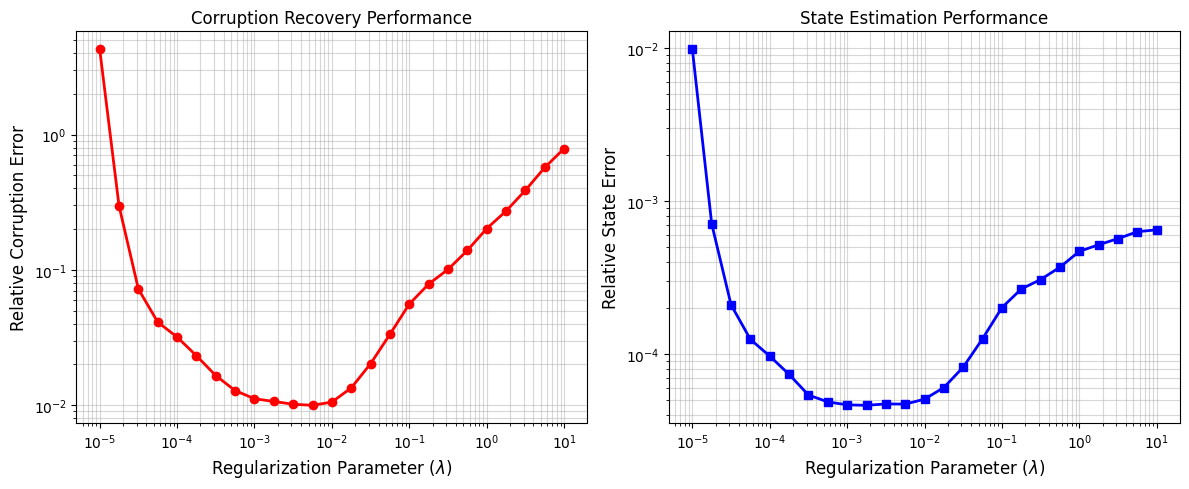

In [14]:
# --- Setup and Simulation ---
n, p, s, T = 10, 5, 2, 100
sigma_w, sigma_v = 0.01, 0.01
B = np.zeros((n, 1))
B[0, 0] = 1

A = generate_A(n)
C = generate_C(n, p)
x_true, y, e_true, A_cl = simulate_system(A, B, C, T, sigma_w, sigma_v, s)

# --- Sweep Lambda ---
lambdas = np.logspace(-5, 1, 25) # From 0.01 to 100
state_errors = []
corr_errors = []

print("Running sweep...")
for l in lambdas:
    x_est, e_est = batch_estimation(A_cl, C, y, lam=l, rho=10.0)
    s_err, c_err = compute_errors(x_true, x_est, e_true, e_est)
    state_errors.append(s_err)
    corr_errors.append(c_err)

# --- Plotting ---
plt.figure(figsize=(12, 5))

# Plot Corruption Error
plt.subplot(1, 2, 1)
plt.loglog(lambdas, corr_errors, 'r-o', linewidth=2)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel(r'Regularization Parameter ($\lambda$)', fontsize=12)
plt.ylabel('Relative Corruption Error', fontsize=12)
plt.title('Corruption Recovery Performance')

# Plot State Error
plt.subplot(1, 2, 2)
plt.loglog(lambdas, state_errors, 'b-s', linewidth=2)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel(r'Regularization Parameter ($\lambda$)', fontsize=12)
plt.ylabel('Relative State Error', fontsize=12)
plt.title('State Estimation Performance')

plt.tight_layout()
plt.show()